# 

In [1]:
from denovo_utils.data.run import Run, Spectrum
from denovo_utils.io.read import load_psmlist, load_psmlist_and_features
from denovo_utils.io.save import save_features
from psm_utils import PSMList
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline
import os
from psm_utils.io import read_file
from psm_utils import PSM, PSMList
from tqdm import tqdm
import pickle
from psm_utils.io import write_file
from peak_pack.utils import calculate_ppm
from typing import List, Optional, Union
import numpy as np
from peak_pack.annotation.evidence import PeptideEvidence
from tqdm import tqdm
from itertools import chain
tqdm.pandas()

2026-09-09 15:11:06.688821: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Modification already exists in ModificationsDB. Skipping.


In [4]:
from figsave import autosave
autosave("figures", formats=("svg", "pdf"))

PosixPath('figures')

# Prepare new gold standard and rescore de novo identifications with new models

In [5]:
root_rescoring = '/public/compomics3/Sam/PXD028735/QExactive/reviewer/rescoring/chimeric'
root_msgf_labels = '/public/compomics3/Sam/PXD028735/QExactive/reviewer/msgf/msgf'
root_mgf = '/public/compomics3/Sam/PXD028735/QExactive/mgf_reformatted'

sage = 'ground_truth.parquet'
msgf = 'msgf.parquet'

run_names = [
    'LFQ_Orbitrap_DDA_Ecoli_01',
    'LFQ_Orbitrap_DDA_Human_01',
    'LFQ_Orbitrap_DDA_QC_01',
    'LFQ_Orbitrap_DDA_Yeast_01'
]

In [6]:
plt.figure(facecolor='none')  # or 'transparent'
sns.set_style("whitegrid")
plt.rcParams['figure.facecolor'] = 'none'
plt.rcParams['axes.facecolor'] = 'none'
plt.rcParams['savefig.transparent'] = True

<Figure size 640x480 with 0 Axes>

## 1. Load the gold standard data

In [4]:
run_dicts = {}

for run_name in tqdm(run_names):
    # Import Sage-MS2Rescore results
    sage_psmlist = load_psmlist_and_features(
        os.path.join(
            root_rescoring,
            run_name,
            'psmlist',
            sage
        ),
        os.path.join(
            root_rescoring,
            run_name,
            'features',
            sage
        )
    )

    # Import rescored MSGF results
    msgf_psmlist = load_psmlist_and_features(
        os.path.join(
            root_rescoring,
            run_name,
            'psmlist',
            msgf
        ),
        feature_path=os.path.join(
            root_rescoring,
            run_name,
            'features',
            msgf
        )
    )
    # Rewrite the decoy labels from original psmlist
    # (This was shuffled during rescoring in 'de novo'-mode)
    msgf_import_labels = read_file(
        os.path.join(
            root_msgf_labels,
            run_name + '.msgf.parquet'
        )
    )
    msgf_psmlist['is_decoy'] = msgf_import_labels['is_decoy']

    # Remove duplicates
    sage_df = sage_psmlist.to_dataframe()
    sage_df = sage_df.drop_duplicates(subset=['spectrum_id', 'peptidoform'])

    msgf_df = msgf_psmlist.to_dataframe()
    # Extract the rescored scores from provenance_data dictionary
    msgf_df['score_ms2rescore'] = msgf_df['provenance_data'].apply(lambda x: x['score_ms2rescore'])
    msgf_df = msgf_df.drop_duplicates(subset=['spectrum_id', 'peptidoform'])

    # Store the results in a dictionary
    run_dicts[run_name] = {
        'sage': sage_df,
        'msgf': msgf_df
    }

100%|██████████| 4/4 [26:42<00:00, 400.68s/it]


In [5]:
all_data = pd.concat([pd.concat([d['sage'], d['msgf']], ignore_index=True) for d in run_dicts.values()], ignore_index=True)
all_data['run'].value_counts()

run
LFQ_Orbitrap_DDA_Human_01    906718
LFQ_Orbitrap_DDA_QC_01       835986
LFQ_Orbitrap_DDA_Yeast_01    757110
LFQ_Orbitrap_DDA_Ecoli_01    373630
Name: count, dtype: int64

## 2. Plot the score distributions

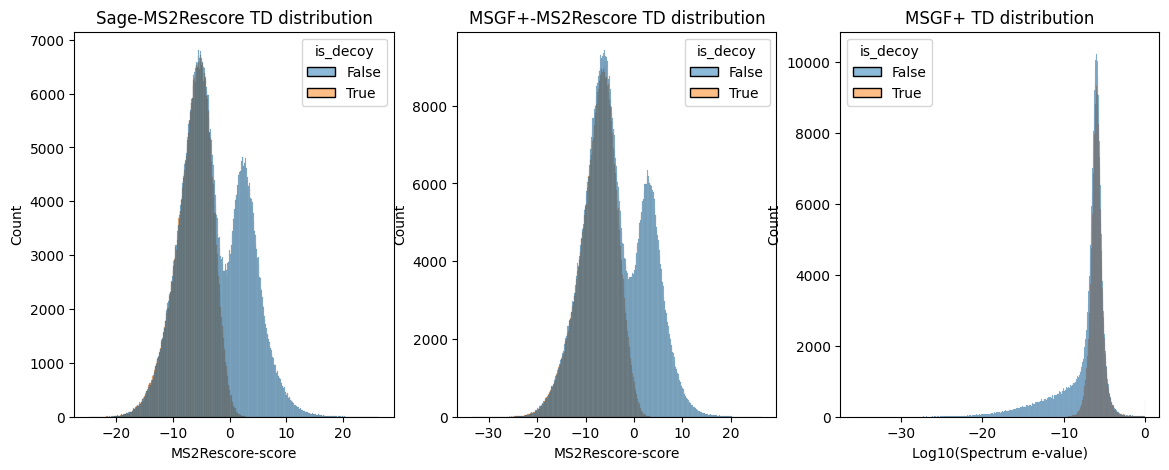

In [6]:
fig, ax = plt.subplots(1,3,figsize=(14,5))

sns.histplot(
    all_data[all_data['source']=='sage'],
    x='score',
    hue='is_decoy',
    ax=ax[0]
)
sns.histplot(
    all_data[all_data['source']=='MS-GF+'],
    x='score_ms2rescore',
    hue='is_decoy',
    ax=ax[1]
)
sns.histplot(
    all_data[all_data['source']=='MS-GF+'],
    x=np.log10(all_data.loc[all_data['source']=='MS-GF+', 'score']),
    hue='is_decoy',
    ax=ax[2]
)

ax[0].set_xlabel('MS2Rescore-score')
ax[1].set_xlabel('MS2Rescore-score')
ax[2].set_xlabel('Log10(Spectrum e-value)')

ax[0].set_title('Sage-MS2Rescore TD distribution')
ax[1].set_title('MSGF+-MS2Rescore TD distribution')
ax[2].set_title('MSGF+ TD distribution')

plt.show('Other_ScoreDistributions')

## 3. Combine the two sources to an expanded gold standard set

In [7]:
def convert_to_psmlist(gt):

    psmlist = []
    for i, row in tqdm(gt.iterrows()):
        # parse fix the metadata
        metadata = row['metadata']
        evidence = str(list(metadata['peptide_evidence'].evidence))
        evidence_labels = str(list(metadata['peptide_evidence'].evidence_labels))
        metadata['PE_evidence'] = evidence
        metadata['PE_evidence_labels'] = evidence_labels
        metadata = {k: str(v) for k, v in metadata.items() if k!='peptide_evidence'}

        # parse fix the provenance data
        provenance_data = {k: str(v) for k, v in row['provenance_data'].items()}

        # Get the rescoring features
        copy_cols = [
            'peptidoform',
            'spectrum_id',
            'run',
            'collection',
            'spectrum',
            'is_decoy',
            'score',
            'qvalue',
            'pep',
            'precursor_mz',
            'retention_time',
            'ion_mobility',
            'protein_list',
            'rank',
            'source',
            'rescoring_features'
        ]

        # Construct the psm
        row_psm = row[copy_cols].to_dict()
        row_psm['metadata'] = metadata
        row_psm['provenance_data'] = provenance_data
    
        psm = PSM(
            **row_psm
        )
        psmlist.append(psm)
    psmlist = PSMList(psm_list=psmlist)
    return psmlist



root_out=root_rescoring
run_dicts_filtered = {}

for run_name, psm_dict in tqdm(run_dicts.items()):
    sage_df = psm_dict['sage']
    msgf_df = psm_dict['msgf']

    # Keep only confident hits
    sage_confident = sage_df.loc[
            (sage_df['qvalue']<.01) &
            (~sage_df['is_decoy']),
    ]
    sage_confident['rank'] = sage_confident.groupby('spectrum_id')['score'].rank(ascending=False, method='first').astype(int)

    msgf_confident = msgf_df.loc[
            (msgf_df['qvalue']<.01) &
            (~msgf_df['is_decoy']),
    ]
    msgf_confident['rank'] = msgf_confident.groupby('spectrum_id')['score'].rank(ascending=True, method='first').astype(int)
    
    # Set MS2Rescore score as the score attribute
    msgf_confident.apply(lambda x: x['provenance_data'].update({'MSGF+-score': x['score']}), axis=1)
    msgf_confident['score'] = msgf_confident.apply(lambda x: x['provenance_data']['score_ms2rescore'], axis=1)

    # Combine the tables
    ### First annotate search engine attribution per PSM (including overlap)
    combination = sage_confident.merge(msgf_confident, on=['spectrum_id', 'peptidoform'], how='left', suffixes=('_sage', '_msgf'))
    ided_in_both = combination['metadata_msgf'].notna()
    sage_confident.loc[ided_in_both.to_numpy(), 'source'] = 'Sage-MSGF+'

    ### Combine the two dataframes
    combined_df = pd.concat([sage_confident, msgf_confident], ignore_index=True)

    ### Drop duplicates based on 'spectrum_id' and 'peptidoform', keeping the first occurrence (reannotated if duplicate)
    combined_df = combined_df.drop_duplicates(subset=['spectrum_id', 'peptidoform'], keep='first')

    # Reassign the ranks
    psmlist_gold_standard = convert_to_psmlist(combined_df)
    psmlist_gold_standard.set_ranks()

    # Write the psmlist to file
    out_path = os.path.join(
            root_out,
            run_name,
            'psmlist',
            'sage_msgf.parquet'
    )
    out_path_features = os.path.join(
            root_out,
            run_name,
            'features',
            'sage_msgf.parquet'
    )
    # write_file(
    #         psm_list=psmlist_gold_standard,
    #         filename=out_path,
    #         filetype='parquet'
    # )

    # save_features(
    #     psm_list=psmlist_gold_standard,
    #     save_path=out_path_features
    # )

    # Save df to dictionary
    run_dicts_filtered[run_name] = psmlist_gold_standard.to_dataframe()

all_data_filtered = pd.concat(
    [i for i in run_dicts_filtered.values()],
    ignore_index=True
)

27815it [00:05, 5380.79it/s]?, ?it/s]
122958it [00:23, 5219.41it/s]0:19,  6.58s/it]
113401it [00:25, 4516.44it/s]0:41, 20.75s/it]
84012it [00:18, 4453.40it/s]00:26, 26.61s/it]
100%|██████████| 4/4 [01:37<00:00, 24.33s/it]


In [ ]:
# all_data_filtered = combine_sage_msgf(
#     run_dicts=run_dicts,
#     root_out=root_rescoring
# )

In [18]:
# Load data
root_rescoring = '/public/compomics3/Sam/PXD028735/QExactive/reviewer/rescoring/chimeric'
root_msgf_labels = '/public/compomics3/Sam/PXD028735/QExactive/reviewer/search/msgf/msgf'
run_names = [
    'LFQ_Orbitrap_DDA_Human_01',
    'LFQ_Orbitrap_DDA_Yeast_01',
    'LFQ_Orbitrap_DDA_Ecoli_01',
    'LFQ_Orbitrap_DDA_QC_01'
]

psmlist_dfs = []
for run_name in run_names:
    psmlist_dfs.append(
        load_psmlist(
        os.path.join(
            root_rescoring,
            run_name,
            'psmlist',
            'sage_msgf.parquet'
        )
    ).to_dataframe()
    )
all_data_filtered = pd.concat(psmlist_dfs, ignore_index=True)

Loading results from sage_msgf.parquet: 100%|██████████| 113401/113401 [00:08<00:00, 13443.03it/s]


## 4. Characteristics of the new gold-standard

### 4.1. Rank attribution

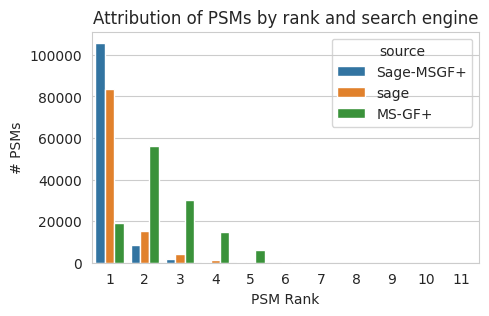

In [11]:
plt.figure(figsize=(5,3))
sns.countplot(
    data=all_data_filtered,
    x='rank',
    hue='source',
)
plt.title('Attribution of PSMs by rank and search engine')
plt.xlabel('PSM Rank')
plt.ylabel('# PSMs')
plt.show('Suppl_GT_Rank')

In [19]:
NEUTRON_MASS = 1.0033
def calculate_ppm(m1, m2, charge=1, isotopes=[0], max_value=50):

    ms1_error = max_value
    isotope_selected = 0

    for isotope in isotopes:
        m2_i = m2 + (isotope * (NEUTRON_MASS / charge))
        ms1_error_i = abs(((m1-m2_i)/m2_i)*10**6)
        if ms1_error > ms1_error_i:
            ms1_error = ms1_error_i
            isotope_selected = isotope*(-1)

    return [ms1_error, isotope_selected]

all_data_filtered['ppm_error/isotope'] = all_data_filtered.progress_apply(
    lambda x:
    calculate_ppm(
        m1=x['peptidoform'].theoretical_mz,
        m2=x['precursor_mz'],
        charge=x['peptidoform'].precursor_charge,
        isotopes=[-2,-1,0,1],
        max_value=10000
    ),
    axis=1
)

all_data_filtered['ppm_error'] = all_data_filtered['ppm_error/isotope'].apply(lambda x: x[0])
all_data_filtered['isotope'] = all_data_filtered['ppm_error/isotope'].apply(lambda x: x[1])

100%|██████████| 348186/348186 [00:06<00:00, 54680.32it/s]


### 4.2. PPM-error and isotope errors

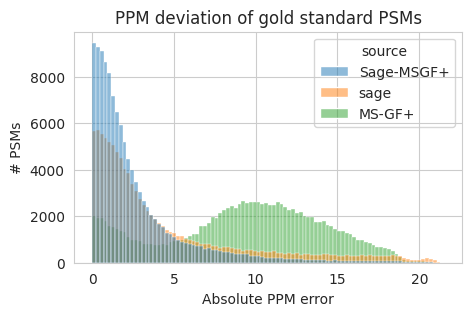

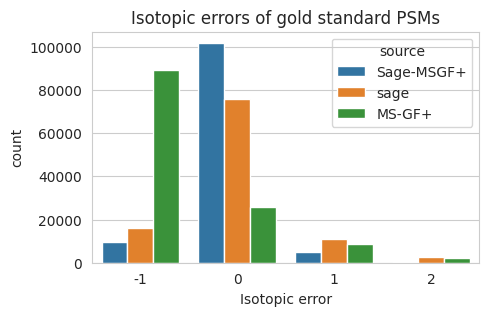

In [13]:
plt.figure(figsize=(5,3))
sns.histplot(
    all_data_filtered,
    hue='source',
    x='ppm_error',
)
plt.title('PPM deviation of gold standard PSMs')
plt.xlabel('Absolute PPM error')
plt.ylabel('# PSMs')
plt.show("Suppl_GT_PPMDeviation")

plt.figure(figsize=(5,3))
sns.countplot(
    all_data_filtered,
    hue='source',
    x='isotope',
)
plt.title('Isotopic errors of gold standard PSMs')
plt.xlabel('Isotopic error')
plt.show("Suppl_GT_IsotopicErrors")

### 4.3. Modification distribution

In [20]:
def get_modifications(peptidoform):
    mod_list = []
    if not peptidoform.is_modified:
        return mod_list
    
    n_mod = peptidoform.properties['n_term']
    if isinstance(n_mod, list):
        mod_list += n_mod

    for aa, mods in peptidoform.parsed_sequence:
        if mods:
            mod_list += mods

    return list(set(mod_list))

all_data_filtered['modifications'] = all_data_filtered['peptidoform'].apply(get_modifications)

In [21]:
# Flatten the modifications column and create dummy columns
modifications_dummies = (
    all_data_filtered['modifications']
    .explode()  # Flatten the list
    .str.get_dummies()  # Create dummy columns
    .groupby(level=0)  # Group back by the original index
    .max()  # Aggregate to ensure presence is captured
)

# Merge the dummy columns back into the original dataframe
all_data_filtered = pd.concat([all_data_filtered, modifications_dummies], axis=1)

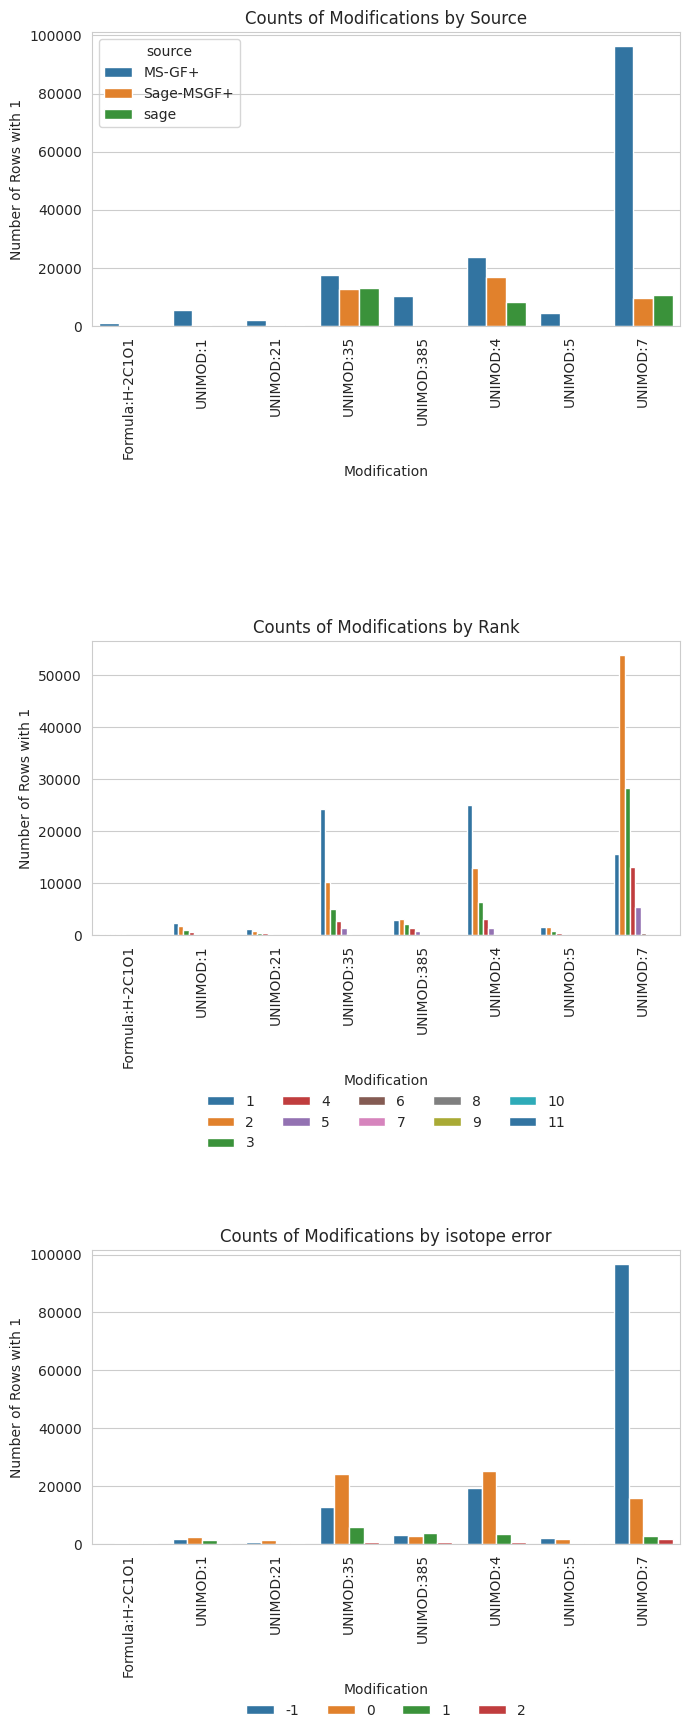

In [ ]:
# Select columns with binary values (1s and 0s)
binary_columns = modifications_dummies.columns

# Count the number of rows with a 1 in each column, grouped by 'source'
modification_counts_by_source = (
    all_data_filtered.groupby('source')[binary_columns]
    .sum()
    .reset_index()
    .melt(id_vars='source', var_name='Modification', value_name='Count')
)
modification_counts_by_rank = (
    all_data_filtered.groupby('rank')[binary_columns]
    .sum()
    .reset_index()
    .melt(id_vars='rank', var_name='Modification', value_name='Count')
)
modification_counts_by_isotope = (
    all_data_filtered.groupby('isotope')[binary_columns]
    .sum()
    .reset_index()
    .melt(id_vars='isotope', var_name='Modification', value_name='Count')
)

palette_rank = sns.color_palette("tab10", n_colors=modification_counts_by_rank['rank'].nunique())
palette_iso = sns.color_palette("tab10", n_colors=modification_counts_by_isotope['isotope'].nunique())

# Plot the barplot
fig, ax = plt.subplots(3,1,figsize=(7,18))
sns.barplot(
    data=modification_counts_by_source,
    x='Modification',
    y='Count',
    hue='source',
    ax=ax[0]
)
sns.barplot(
    data=modification_counts_by_rank,
    x='Modification',
    y='Count',
    hue='rank',
    palette=palette_rank,
    ax=ax[1]
)
sns.barplot(
    data=modification_counts_by_isotope,
    x='Modification',
    y='Count',
    hue='isotope',
    palette=palette_iso,
    ax=ax[2]
)

for i in [1, 2]:
    ax[i].legend(
        loc='upper center',
        bbox_to_anchor=(0.5, -0.50),  # move below plot
        ncol=5,                      # adjust depending on number of categories
        frameon=False
    )

ax[0].tick_params(axis='x', rotation=90)
ax[0].set_title('Counts of Modifications by Source')
ax[0].set_ylabel('Number of Rows with 1')
ax[0].set_xlabel('Modification')

ax[1].tick_params(axis='x', rotation=90)
ax[1].set_title('Counts of Modifications by Rank')
ax[1].set_ylabel('Number of Rows with 1')
ax[1].set_xlabel('Modification')

ax[2].tick_params(axis='x', rotation=90)
ax[2].set_title('Counts of Modifications by isotope error')
ax[2].set_ylabel('Number of Rows with 1')
ax[2].set_xlabel('Modification')
plt.tight_layout()
plt.show("Suppl_GT_ModPanel")

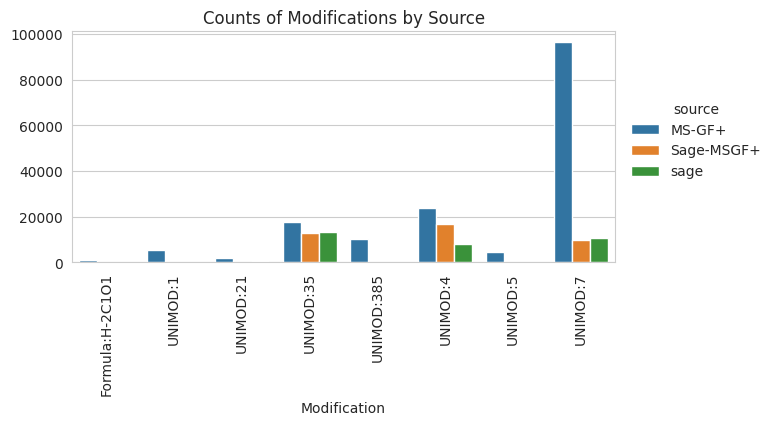

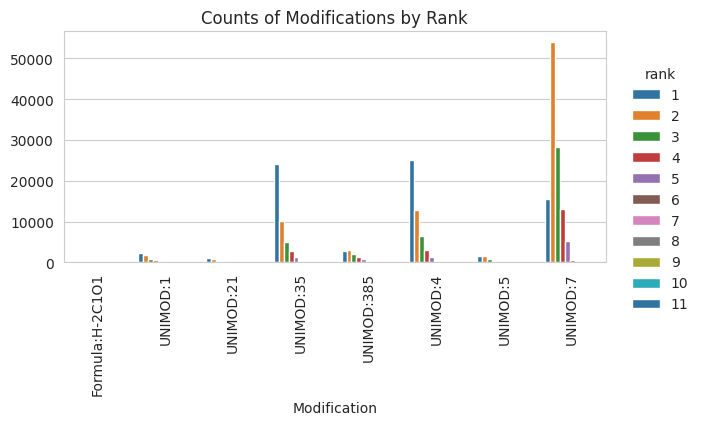

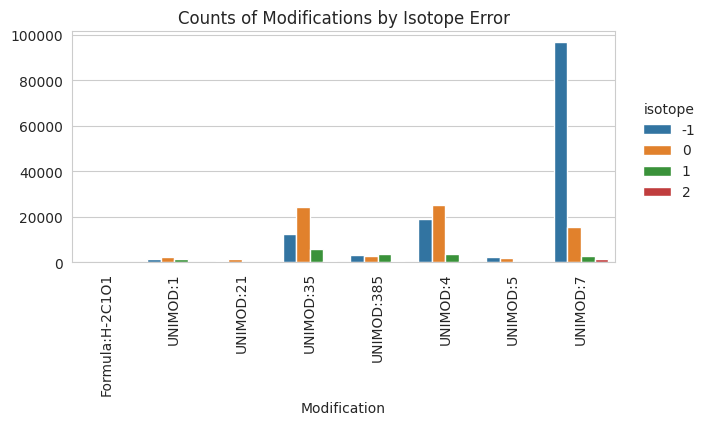

In [25]:
# ---- Plot 1: Source ----
fig, ax = plt.subplots(figsize=(7, 3))

sns.barplot(
    data=modification_counts_by_source,
    x='Modification',
    y='Count',
    hue='source',
    ax=ax
)

ax.tick_params(axis='x', rotation=90)
ax.set_title('Counts of Modifications by Source')
ax.set_ylabel('')
ax.set_xlabel('Modification')

sns.move_legend(
    ax,
    loc='upper center',
    bbox_to_anchor=(1.15, .75),
    frameon=False
)
plt.show("Suppl_GT_ModSource")


# ---- Plot 2: Rank ----
fig, ax = plt.subplots(figsize=(7, 3))

sns.barplot(
    data=modification_counts_by_rank,
    x='Modification',
    y='Count',
    hue='rank',
    palette=palette_rank,
    ax=ax
)

ax.tick_params(axis='x', rotation=90)
ax.set_title('Counts of Modifications by Rank')
ax.set_ylabel('')
ax.set_xlabel('Modification')

sns.move_legend(
    ax,
    loc='upper center',
    bbox_to_anchor=(1.1, .9),
    frameon=False
)
plt.show("Suppl_GT_ModRank")


# ---- Plot 3: Isotope ----
fig, ax = plt.subplots(figsize=(7, 3))

sns.barplot(
    data=modification_counts_by_isotope,
    x='Modification',
    y='Count',
    hue='isotope',
    palette=palette_iso,
    ax=ax
)

ax.tick_params(axis='x', rotation=90)
ax.set_title('Counts of Modifications by Isotope Error')
ax.set_ylabel('')
ax.set_xlabel('Modification')

sns.move_legend(
    ax,
    loc='upper center',
    bbox_to_anchor=(1.1, .75),
    frameon=False
)
plt.show("Suppl_GT_ModIsotope")

### Generate source data excel file

In [23]:
import numpy as np
FIGURE = "Supplementary Figure 1"   # set the real number before submission
OUT = "source_data/Source_Data_Suppl_1.xlsx"

sheets = {}

# --- A: countplot(x='rank', hue='source') ---------------------------------
A = (all_data_filtered.groupby(['rank', 'source']).size()
     .rename('count').reset_index())
A.insert(0, 'panel', 'A')
sheets['A'] = A

# --- C: countplot(x='isotope', hue='source') -------------------------------
C = (all_data_filtered.groupby(['isotope', 'source']).size()
     .rename('count').reset_index())
C.insert(0, 'panel', 'C')
sheets['C'] = C

# --- B: histplot(x='ppm_error', hue='source') -------------------------------
edges = np.histogram_bin_edges(all_data_filtered['ppm_error'].dropna(), bins='auto')
rows = []
for src, gdf in all_data_filtered.groupby('source'):
    counts, _ = np.histogram(gdf['ppm_error'].dropna(), bins=edges)
    rows.append(pd.DataFrame({'source': src, 'bin_left': edges[:-1],
                              'bin_right': edges[1:], 'count': counts}))
B = pd.concat(rows, ignore_index=True)
B.insert(0, 'panel', 'B')
sheets['B'] = B

# --- D, E, F: already-aggregated bar data, used as-is ------------------------
D = modification_counts_by_source.copy(); D.insert(0, 'panel', 'D')
E = modification_counts_by_rank.copy();   E.insert(0, 'panel', 'E')
F = modification_counts_by_isotope.copy();F.insert(0, 'panel', 'F')
sheets['D'], sheets['E'], sheets['F'] = D, E, F

with pd.ExcelWriter(OUT, engine='openpyxl') as xl:
    for letter in ['A', 'B', 'C', 'D', 'E', 'F']:
        df = sheets[letter]
        df.insert(0, 'figure', FIGURE)
        df.to_excel(xl, sheet_name=letter, index=False)

print(f"wrote {OUT}: sheets {list(sheets)}")

wrote source_data/Source_Data_Suppl_1.xlsx: sheets ['A', 'C', 'B', 'D', 'E', 'F']


---

In [28]:
all_data_filtered['sequence'] = all_data_filtered.peptidoform.apply(lambda x: x.proforma)

In [30]:
all_data_filtered.to_csv("source_data/supplemental_S1.csv", columns=all_data_filtered.columns.drop("rescoring_features"), index=False)

#### Check the entrapment FDR

In [127]:
# Define a function to calculate the percentage of rows for each species
def calculate_species_percentage(df, species_list):
    percentages = {}
    for species in species_list:
        percentages[species] = df['protein_list'].apply(
            lambda proteins: any(species.upper() in protein.upper() for protein in proteins)
        ).mean() * 100
    return percentages

# Group by 'run' and calculate percentages for each species
species_percentages = {}
for run in all_data_filtered['run'].unique():
    run_df = all_data_filtered[all_data_filtered['run'] == run]
    species_percentages[run] = calculate_species_percentage(run_df, species)

# Convert the result to a DataFrame for better visualization
species_percentages_df = pd.DataFrame(species_percentages).T
species_percentages_df.columns = [f"{s}_percentage" for s in species]
species_percentages_df

,ecoli_percentage,human_percentage,yeast_percentage
LFQ_Orbitrap_DDA_Ecoli_01,96.552220,2.433939,0.934747
LFQ_Orbitrap_DDA_Human_01,0.223654,97.837473,1.766457
LFQ_Orbitrap_DDA_QC_01,3.207203,74.794755,22.060652
LFQ_Orbitrap_DDA_Yeast_01,0.384469,3.122173,97.411084


In [132]:
all_data_filtered['contains_contaminant'] = all_data_filtered['protein_list'].apply(
    lambda x: any(['Cont_' in prot for prot in x])
)

In [137]:
# Create boolean columns for each species
species = ['HUMAN', 'ECOLI', 'YEAST']
for sp in species:
    all_data_filtered[sp] = all_data_filtered['protein_list'].apply(
        lambda proteins: any(sp in protein.upper() for protein in proteins)
    )

# Create a column to count the number of species identified in each row
all_data_filtered['n_species'] = all_data_filtered[species].sum(axis=1)

# Calculate the percentage of species representation for each run
species_percentages = (
    all_data_filtered[
        (~all_data_filtered['contains_contaminant']) &
        (all_data_filtered['n_species']==1)
    ].groupby('run')[species]
    .mean()
    .mul(100)
    .reset_index()
)

species_percentages

,run,HUMAN,ECOLI,YEAST
0,LFQ_Orbitrap_DDA_Ecoli_01,1.838182,97.482093,0.679725
1,LFQ_Orbitrap_DDA_Human_01,99.107721,0.191758,0.700521
2,LFQ_Orbitrap_DDA_QC_01,74.798987,3.258864,21.942149
3,LFQ_Orbitrap_DDA_Yeast_01,1.721337,0.237004,98.041659


In [144]:
all_data_filtered['source'].value_counts()

source
MS-GF+        126071
Sage-MSGF+    116877
sage          105238
Name: count, dtype: int64

# 5. Rescore the de novo results with the new mokapot models

In [102]:
from denovo_utils.rescoring import DeNovoRescorer
from denovo_utils.io.read import (
    load_configuration,
    load_psmlist_and_features
)
from glob import glob

In [106]:
sorted([i.split('/')[-1] for i in list(glob('/public/compomics3/Sam/PXD028735/QExactive/reviewer/rescoring/chimeric/LFQ_Orbitrap_DDA_Ecoli_01/psmlist/*'))])

['adanovo.instanovoplus.parquet',
 'adanovo.instanovoplus_v0.parquet',
 'adanovo.parquet',
 'adanovo.spectralis.parquet',
 'casanovo.instanovoplus.parquet',
 'casanovo.instanovoplus_v0.parquet',
 'casanovo.parquet',
 'casanovo.spectralis.parquet',
 'contranovo.instanovoplus.parquet',
 'contranovo.instanovoplus_v0.parquet',
 'contranovo.parquet',
 'contranovo.spectralis.parquet',
 'ground_truth.parquet',
 'instanovo.instanovoplus.parquet',
 'instanovo.instanovoplus_v0.parquet',
 'instanovo.parquet',
 'instanovo.spectralis.parquet',
 'instanovo_v0.parquet',
 'instanovo_v0.spectralis.parquet',
 'msgf.parquet',
 'novob.instanovoplus.parquet',
 'novob.instanovoplus_v0.parquet',
 'novob.parquet',
 'novob.spectralis.parquet',
 'pepnet.instanovoplus.parquet',
 'pepnet.instanovoplus_v0.parquet',
 'pepnet.parquet',
 'pepnet.spectralis.parquet',
 'pihelixnovo.instanovoplus.parquet',
 'pihelixnovo.instanovoplus_v0.parquet',
 'pihelixnovo.parquet',
 'pihelixnovo.spectralis.parquet',
 'piprimenovo.i

In [117]:
import gc
from denovo_utils.io.save import save_psmlist, save_features

results_to_rescore = [
    'adanovo.instanovoplus.parquet',
    'adanovo.instanovoplus_v0.parquet',
    'adanovo.parquet',
    'adanovo.spectralis.parquet',
    'casanovo.instanovoplus.parquet',
    'casanovo.instanovoplus_v0.parquet',
    'casanovo.parquet',
    'casanovo.spectralis.parquet',
    'contranovo.instanovoplus.parquet',
    'contranovo.instanovoplus_v0.parquet',
    'contranovo.parquet',
    'contranovo.spectralis.parquet',
    'instanovo.instanovoplus.parquet',
    'instanovo.instanovoplus_v0.parquet',
    'instanovo.parquet',
    'instanovo.spectralis.parquet',
    'instanovo_v0.parquet',
    'instanovo_v0.spectralis.parquet',
    'novob.instanovoplus.parquet',
    'novob.instanovoplus_v0.parquet',
    'novob.parquet',
    'novob.spectralis.parquet',
    'pepnet.instanovoplus.parquet',
    'pepnet.instanovoplus_v0.parquet',
    'pepnet.parquet',
    'pepnet.spectralis.parquet',
    'pihelixnovo.instanovoplus.parquet',
    'pihelixnovo.instanovoplus_v0.parquet',
    'pihelixnovo.parquet',
    'pihelixnovo.spectralis.parquet',
    'piprimenovo.instanovoplus.parquet',
    'piprimenovo.instanovoplus_v0.parquet',
    'piprimenovo.parquet',
    'piprimenovo.spectralis.parquet',
]

for run_name in run_names:
    # Just used to complete the config, is not used actually
    gold_standard_path = os.path.join(
        root_rescoring,
        run_name,
        'psmlist',
        'ground_truth.parquet'
    )
    spectrum_path = os.path.join(
        root_mgf,
        run_name+'.mgf'
    )

    configuration = load_configuration(
        path_config_ms2rescore='/home/sam/denovo/DeNovo_Benchmark/configs/ms2rescore/chimeric.json',
        psm_file=gold_standard_path,
        spectrum_path=spectrum_path
    )
    rescorer = DeNovoRescorer(configuration=configuration)
    rescorer.load(
        calibration_folder=os.path.join(
            root_rescoring,
            run_name,
            'calibration'
        ),
        mokapot_folder=os.path.join(
            root_rescoring,
            run_name,
            'mokapot'
        ),
    )

    for denovo_file in tqdm(results_to_rescore, desc=f'Rescoring de novo files for {run_name}'):
        save_psm_path = os.path.join(root_rescoring, run_name, 'psmlist', denovo_file)
        save_feature_path = os.path.join(root_rescoring, run_name, 'features', denovo_file)

        # Load the de novo psmlist and features
        psm_list = load_psmlist_and_features(psm_path=save_psm_path, feature_path=save_feature_path)
        # Add some missing features that are newly added
        for psm in psm_list:
            psm['rescoring_features'].update(
                {
                    'peptide_len': len(psm['peptidoform']),
                    'experimental_mz': psm['precursor_mz']
                }
            )
        # Add the deeplc features with the new calibrated models
        rescorer.add_features(psm_list=psm_list, feature_types=["deeplc", ])
        # Rescore
        rescorer.rescore(psm_list, denovo=True)
        # Overwrite
        save_features(
            psm_list,
            save_feature_path
        )            
        save_psmlist(
            psm_list,
            save_psm_path
        )
        gc.collect()

Loading results from adanovo.instanovoplus.parquet: 100%|██████████| 61843/61843 [00:03<00:00, 16326.41it/s]
Loading results from adanovo.instanovoplus_v0.parquet: 100%|██████████| 61832/61832 [00:03<00:00, 17883.12it/s]
Loading results from adanovo.spectralis.parquet: 100%|██████████| 61843/61843 [00:04<00:00, 15349.20it/s]
Loading results from casanovo.instanovoplus.parquet: 100%|██████████| 61872/61872 [00:03<00:00, 15952.24it/s]
Loading results from casanovo.instanovoplus_v0.parquet: 100%|██████████| 61866/61866 [00:03<00:00, 17989.56it/s]
Loading results from casanovo.spectralis.parquet: 100%|██████████| 61876/61876 [00:04<00:00, 15176.74it/s]
Loading results from contranovo.instanovoplus.parquet: 100%|██████████| 30930/30930 [00:01<00:00, 15603.05it/s]
Loading results from contranovo.instanovoplus_v0.parquet: 100%|██████████| 31015/31015 [00:01<00:00, 17437.19it/s]
Loading results from contranovo.parquet: 100%|██████████| 30999/30999 [00:02<00:00, 13471.07it/s]9s/it] 
Loading res

# 6. Create other ground-truths

## 6.1. TimsTOF

In [228]:
root_rescoring = '/public/compomics3/Sam/PXD028735/timsTOF/reviewer/rescoring'
root_msgf_labels = '/public/compomics3/Sam/PXD028735/timsTOF/reviewer/search/msgf/msgf'
run_names = [
    'LFQ_timsTOFPro_PASEF_Human_01',
    'LFQ_timsTOFPro_PASEF_Yeast_01',
    'LFQ_timsTOFPro_PASEF_Ecoli_01',
    'LFQ_timsTOFPro_PASEF_QC_01'
]

run_dicts = {}

for run_name in tqdm(run_names):
    # Import Sage-MS2Rescore results
    sage_psmlist = load_psmlist(
        os.path.join(
            root_rescoring,
            run_name,
            'psmlist',
            sage
        )
    )

    msgf_psmlist = read_file(
        os.path.join(
            root_msgf_labels,
            run_name + '.msgf.parquet'
        )
    )

    # Remove duplicates
    sage_df = sage_psmlist.to_dataframe()
    sage_df = sage_df.drop_duplicates(subset=['spectrum_id', 'peptidoform'])

    msgf_df = msgf_psmlist.to_dataframe()
    # Extract the rescored scores from provenance_data dictionary
    msgf_df['score_ms2rescore'] = msgf_df['score']
    msgf_df = msgf_df.drop_duplicates(subset=['spectrum_id', 'peptidoform'])

    # Store the results in a dictionary
    run_dicts[run_name] = {
        'sage': sage_df,
        'msgf': msgf_df
    }

100%|██████████| 4/4 [06:20<00:00, 95.05s/it]


In [230]:
def convert_to_psmlist_simplified(gt):

    psmlist = []
    for i, row in tqdm(gt.iterrows()):
        # parse fix the metadata
        metadata = {}

        # parse fix the provenance data
        provenance_data = {k: str(v) for k, v in row['provenance_data'].items()}

        # Get the rescoring features
        copy_cols = [
            'peptidoform',
            'spectrum_id',
            'run',
            'collection',
            'spectrum',
            'is_decoy',
            'score',
            'qvalue',
            'pep',
            'precursor_mz',
            'retention_time',
            'ion_mobility',
            'protein_list',
            'rank',
            'source',
            'rescoring_features'
        ]

        # Construct the psm
        row_psm = row[copy_cols].to_dict()
        row_psm['metadata'] = metadata
        row_psm['provenance_data'] = provenance_data
    
        psm = PSM(
            **row_psm
        )
        psmlist.append(psm)
    psmlist = PSMList(psm_list=psmlist)
    return psmlist


In [231]:
root_out=root_rescoring
run_dicts_filtered = {}

for run_name, psm_dict in tqdm(run_dicts.items()):
    sage_df = psm_dict['sage']
    msgf_df = psm_dict['msgf']

    # Keep only confident hits
    sage_confident = sage_df.loc[
            (sage_df['qvalue']<.01) &
            (~sage_df['is_decoy']),
    ]
    sage_confident['rank'] = sage_confident.groupby('spectrum_id')['score'].rank(ascending=False, method='first').astype(int)

    msgf_confident = msgf_df.loc[
            (msgf_df['qvalue']<.01) &
            (~msgf_df['is_decoy']),
    ]
    msgf_confident['rank'] = msgf_confident.groupby('spectrum_id')['score'].rank(ascending=True, method='first').astype(int)
    
    # Set MS2Rescore score as the score attribute
    msgf_confident.apply(lambda x: x['provenance_data'].update({'MSGF+-score': x['score']}), axis=1)
    # msgf_confident['score'] = msgf_confident.apply(lambda x: x['provenance_data']['score_ms2rescore'], axis=1)

    # Combine the tables
    ### First annotate search engine attribution per PSM (including overlap)
    combination = sage_confident.merge(msgf_confident, on=['spectrum_id', 'peptidoform'], how='left', suffixes=('_sage', '_msgf'))
    ided_in_both = combination['metadata_msgf'].notna()
    sage_confident.loc[ided_in_both.to_numpy(), 'source'] = 'Sage-MSGF+'

    ### Combine the two dataframes
    combined_df = pd.concat([sage_confident, msgf_confident], ignore_index=True)

    ### Drop duplicates based on 'spectrum_id' and 'peptidoform', keeping the first occurrence (reannotated if duplicate)
    combined_df = combined_df.drop_duplicates(subset=['spectrum_id', 'peptidoform'], keep='first')

    # Reassign the ranks
    psmlist_gold_standard = convert_to_psmlist_simplified(combined_df)
    psmlist_gold_standard.set_ranks()

    # Write the psmlist to file
    out_path = os.path.join(
            root_out,
            run_name,
            'psmlist',
            'sage_msgf.parquet'
    )
    out_path_features = os.path.join(
            root_out,
            run_name,
            'features',
            'sage_msgf.parquet'
    )

    print(f'writing to {out_path}')
    write_file(
            psm_list=psmlist_gold_standard,
            filename=out_path,
            filetype='parquet'
    )

    # save_features(
    #     psm_list=psmlist_gold_standard,
    #     save_path=out_path_features
    # )

    # Save df to dictionary
    run_dicts_filtered[run_name] = psmlist_gold_standard.to_dataframe()

    all_data_filtered = pd.concat(
        [i for i in run_dicts_filtered.values()],
        ignore_index=True
    )

185163it [00:28, 6499.87it/s], ?it/s]


writing to /public/compomics3/Sam/PXD028735/timsTOF/reviewer/rescoring/LFQ_timsTOFPro_PASEF_Human_01/psmlist/sage_msgf.parquet


136947it [00:21, 6499.09it/s]2:05, 41.72s/it]


writing to /public/compomics3/Sam/PXD028735/timsTOF/reviewer/rescoring/LFQ_timsTOFPro_PASEF_Yeast_01/psmlist/sage_msgf.parquet


98685it [00:14, 6759.69it/s]01:12, 36.25s/it]


writing to /public/compomics3/Sam/PXD028735/timsTOF/reviewer/rescoring/LFQ_timsTOFPro_PASEF_Ecoli_01/psmlist/sage_msgf.parquet


177635it [00:26, 6606.42it/s]0:29, 29.79s/it]


writing to /public/compomics3/Sam/PXD028735/timsTOF/reviewer/rescoring/LFQ_timsTOFPro_PASEF_QC_01/psmlist/sage_msgf.parquet


100%|██████████| 4/4 [02:17<00:00, 34.42s/it]


In [ ]:
root_rescoring = '/public/compomics3/Sam/PXD028735/timsTOF/reviewer/rescoring'
root_msgf_labels = '/public/compomics3/Sam/PXD028735/timsTOF/reviewer/search/msgf/msgf'
run_names = [
    'LFQ_timsTOFPro_PASEF_Human_01',
    'LFQ_timsTOFPro_PASEF_Yeast_01',
    'LFQ_timsTOFPro_PASEF_Ecoli_01',
    'LFQ_timsTOFPro_PASEF_QC_01'
]

psmlist_dfs = []
for run_name in run_names:
    psmlist_dfs.append(
        load_psmlist(
        os.path.join(
            root_rescoring,
            run_name,
            'psmlist',
            'sage_msgf.parquet'
        )
    ).to_dataframe()
    )
psmlist_dfs = pd.concat(psmlist_dfs)

In [243]:
psmlist_dfs['source'].value_counts()

source
MS-GF+        247268
sage          217190
Sage-MSGF+    133972
Name: count, dtype: int64

In [ ]:
plot_characteristics(all_data_filtered)

## 6.2. Metaproteomics

In [232]:
root_rescoring = '/public/compomics3/Sam/PXD023217/reviewer/rescoring'
root_msgf_labels = '/public/compomics3/Sam/PXD023217/reviewer/search/msgf/msgf'
run_names = [
    'S03',
    'S05',
    'S07'
]

run_dicts = {}

for run_name in tqdm(run_names):
    # Import Sage-MS2Rescore results
    sage_psmlist = load_psmlist(
        os.path.join(
            root_rescoring,
            run_name,
            'psmlist',
            sage
        )
    )

    # Import rescored MSGF results
    msgf_psmlist = load_psmlist(
        os.path.join(
            root_rescoring,
            run_name,
            'psmlist',
            msgf
        )
    )
    # Rewrite the decoy labels from original psmlist
    # (This was shuffled during rescoring in 'de novo'-mode)
    msgf_import_labels = read_file(
        os.path.join(
            root_msgf_labels,
            run_name + '.msgf.parquet'
        )
    )
    msgf_psmlist['is_decoy'] = msgf_import_labels['is_decoy']

    # Remove duplicates
    sage_df = sage_psmlist.to_dataframe()
    sage_df = sage_df.drop_duplicates(subset=['spectrum_id', 'peptidoform'])

    msgf_df = msgf_psmlist.to_dataframe()
    # Extract the rescored scores from provenance_data dictionary
    msgf_df['score_ms2rescore'] = msgf_df['provenance_data'].apply(lambda x: x['score_ms2rescore'])
    msgf_df = msgf_df.drop_duplicates(subset=['spectrum_id', 'peptidoform'])

    # Store the results in a dictionary
    run_dicts[run_name] = {
        'sage': sage_df,
        'msgf': msgf_df
    }

100%|██████████| 3/3 [18:27<00:00, 369.15s/it]


In [233]:
root_out=root_rescoring
run_dicts_filtered = {}

for run_name, psm_dict in tqdm(run_dicts.items()):
    sage_df = psm_dict['sage']
    msgf_df = psm_dict['msgf']

    # Keep only confident hits
    sage_confident = sage_df.loc[
            (sage_df['qvalue']<.01) &
            (~sage_df['is_decoy']),
    ]
    sage_confident['rank'] = sage_confident.groupby('spectrum_id')['score'].rank(ascending=False, method='first').astype(int)

    msgf_confident = msgf_df.loc[
            (msgf_df['qvalue']<.01) &
            (~msgf_df['is_decoy']),
    ]
    msgf_confident['rank'] = msgf_confident.groupby('spectrum_id')['score'].rank(ascending=True, method='first').astype(int)
    
    # Set MS2Rescore score as the score attribute
    msgf_confident.apply(lambda x: x['provenance_data'].update({'MSGF+-score': x['score']}), axis=1)
    # msgf_confident['score'] = msgf_confident.apply(lambda x: x['provenance_data']['score_ms2rescore'], axis=1)

    # Combine the tables
    ### First annotate search engine attribution per PSM (including overlap)
    combination = sage_confident.merge(msgf_confident, on=['spectrum_id', 'peptidoform'], how='left', suffixes=('_sage', '_msgf'))
    ided_in_both = combination['metadata_msgf'].notna()
    sage_confident.loc[ided_in_both.to_numpy(), 'source'] = 'Sage-MSGF+'

    ### Combine the two dataframes
    combined_df = pd.concat([sage_confident, msgf_confident], ignore_index=True)

    ### Drop duplicates based on 'spectrum_id' and 'peptidoform', keeping the first occurrence (reannotated if duplicate)
    combined_df = combined_df.drop_duplicates(subset=['spectrum_id', 'peptidoform'], keep='first')

    # Reassign the ranks
    psmlist_gold_standard = convert_to_psmlist_simplified(combined_df)
    psmlist_gold_standard.set_ranks()

    # Write the psmlist to file
    out_path = os.path.join(
            root_out,
            run_name,
            'psmlist',
            'sage_msgf.parquet'
    )
    out_path_features = os.path.join(
            root_out,
            run_name,
            'features',
            'sage_msgf.parquet'
    )

    print(f'writing to {out_path}')
    write_file(
            psm_list=psmlist_gold_standard,
            filename=out_path,
            filetype='parquet'
    )

    # save_features(
    #     psm_list=psmlist_gold_standard,
    #     save_path=out_path_features
    # )

    # Save df to dictionary
    run_dicts_filtered[run_name] = psmlist_gold_standard.to_dataframe()

    all_data_filtered = pd.concat(
        [i for i in run_dicts_filtered.values()],
        ignore_index=True
    )

168295it [00:25, 6578.28it/s], ?it/s]


writing to /public/compomics3/Sam/PXD023217/reviewer/rescoring/S03/psmlist/sage_msgf.parquet


233076it [00:37, 6210.17it/s]1:36, 48.37s/it]


writing to /public/compomics3/Sam/PXD023217/reviewer/rescoring/S05/psmlist/sage_msgf.parquet


55526it [00:08, 6611.83it/s]00:54, 54.80s/it]


writing to /public/compomics3/Sam/PXD023217/reviewer/rescoring/S07/psmlist/sage_msgf.parquet


100%|██████████| 3/3 [02:02<00:00, 40.73s/it]


In [236]:
all_data_filtered[['run', 'spectrum_id']].drop_duplicates()

,run,spectrum_id
0,S03,controllerType=0 controllerNumber=1 scan=116726
1,S03,controllerType=0 controllerNumber=1 scan=128536
2,S03,controllerType=0 controllerNumber=1 scan=106788
3,S03,controllerType=0 controllerNumber=1 scan=102899
4,S03,controllerType=0 controllerNumber=1 scan=43936
...,...,...
456883,S07,controllerType=0 controllerNumber=1 scan=21513
456889,S07,controllerType=0 controllerNumber=1 scan=4415
456890,S07,controllerType=0 controllerNumber=1 scan=22163
456895,S07,controllerType=0 controllerNumber=1 scan=7740


In [237]:
all_data_filtered['source'].value_counts()

source
MS-GF+        225781
Sage-MSGF+    167151
sage           63965
Name: count, dtype: int64

In [193]:
def plot_characteristics(all_data_filtered):
    # Add ppm_error and isotope info
    all_data_filtered['ppm_error/isotope'] = all_data_filtered.progress_apply(
        lambda x:
        calculate_ppm(
            m1=x['peptidoform'].theoretical_mz,
            m2=x['precursor_mz'],
            charge=x['peptidoform'].precursor_charge,
            isotopes=[-2,-1,0,1],
            max_value=10000
        ),
        axis=1
    )

    all_data_filtered['ppm_error'] = all_data_filtered['ppm_error/isotope'].apply(lambda x: x[0])
    all_data_filtered['isotope'] = all_data_filtered['ppm_error/isotope'].apply(lambda x: x[1])

    # Add mod info
    all_data_filtered['modifications'] = all_data_filtered['peptidoform'].apply(get_modifications)
    # Flatten the modifications column and create dummy columns
    modifications_dummies = (
        all_data_filtered['modifications']
        .explode()  # Flatten the list
        .str.get_dummies()  # Create dummy columns
        .groupby(level=0)  # Group back by the original index
        .max()  # Aggregate to ensure presence is captured
    )

    # Merge the dummy columns back into the original dataframe
    all_data_filtered = pd.concat([all_data_filtered, modifications_dummies], axis=1)

    # Plot rank and search engine
    plt.figure(figsize=(5,3))
    sns.countplot(
        data=all_data_filtered,
        x='rank',
        hue='source',
    )
    plt.title('Attribution of PSMs by rank and search engine')
    plt.xlabel('PSM Rank')
    plt.ylabel('# PSMs')
    plt.show()

    plt.figure(figsize=(5,3))
    sns.histplot(
        all_data_filtered,
        hue='source',
        x='ppm_error',
    )
    plt.title('PPM deviation of gold standard PSMs')
    plt.xlabel('Absolute PPM error')
    plt.ylabel('# PSMs')
    plt.show()

    plt.figure(figsize=(5,3))
    sns.countplot(
        all_data_filtered,
        hue='source',
        x='isotope',
    )
    plt.title('Isotopic errors of gold standard PSMs')
    plt.xlabel('Isotopic error')
    plt.show()

    # Select columns with binary values (1s and 0s)
    binary_columns = modifications_dummies.columns

    # Count the number of rows with a 1 in each column, grouped by 'source'
    modification_counts_by_source = (
        all_data_filtered.groupby('source')[binary_columns]
        .sum()
        .reset_index()
        .melt(id_vars='source', var_name='Modification', value_name='Count')
    )
    modification_counts_by_rank = (
        all_data_filtered.groupby('rank')[binary_columns]
        .sum()
        .reset_index()
        .melt(id_vars='rank', var_name='Modification', value_name='Count')
    )
    modification_counts_by_isotope = (
        all_data_filtered.groupby('isotope')[binary_columns]
        .sum()
        .reset_index()
        .melt(id_vars='isotope', var_name='Modification', value_name='Count')
    )

    palette_rank = sns.color_palette("tab10", n_colors=modification_counts_by_rank['rank'].nunique())
    palette_iso = sns.color_palette("tab10", n_colors=modification_counts_by_isotope['isotope'].nunique())

    # Plot the barplot
    fig, ax = plt.subplots(1,3,figsize=(18, 7))
    sns.barplot(
        data=modification_counts_by_source,
        x='Modification',
        y='Count',
        hue='source',
        ax=ax[0]
    )
    sns.barplot(
        data=modification_counts_by_rank,
        x='Modification',
        y='Count',
        hue='rank',
        palette=palette_rank,
        ax=ax[1]
    )
    sns.barplot(
        data=modification_counts_by_isotope,
        x='Modification',
        y='Count',
        hue='isotope',
        palette=palette_iso,
        ax=ax[2]
    )

    for i in [1, 2]:
        ax[i].legend(
            loc='upper center',
            bbox_to_anchor=(0.5, -0.50),  # move below plot
            ncol=5,                      # adjust depending on number of categories
            frameon=False
        )

    ax[0].tick_params(axis='x', rotation=90)
    ax[0].set_title('Counts of Modifications by Source')
    ax[0].set_ylabel('Number of Rows with 1')
    ax[0].set_xlabel('Modification')

    ax[1].tick_params(axis='x', rotation=90)
    ax[1].set_title('Counts of Modifications by Rank')
    ax[1].set_ylabel('Number of Rows with 1')
    ax[1].set_xlabel('Modification')

    ax[2].tick_params(axis='x', rotation=90)
    ax[2].set_title('Counts of Modifications by isotope error')
    ax[2].set_ylabel('Number of Rows with 1')
    ax[2].set_xlabel('Modification')
    plt.tight_layout()
    plt.show()

100%|██████████| 168295/168295 [00:03<00:00, 53863.79it/s]


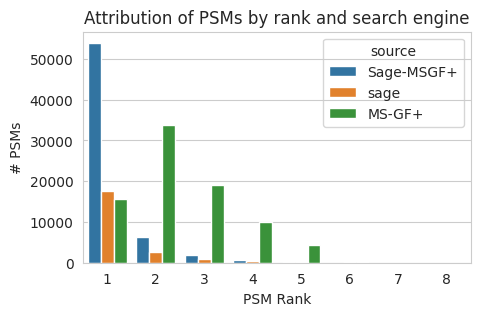

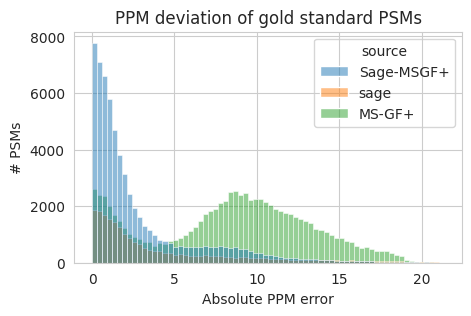

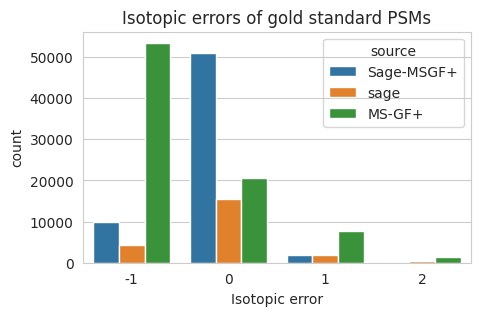

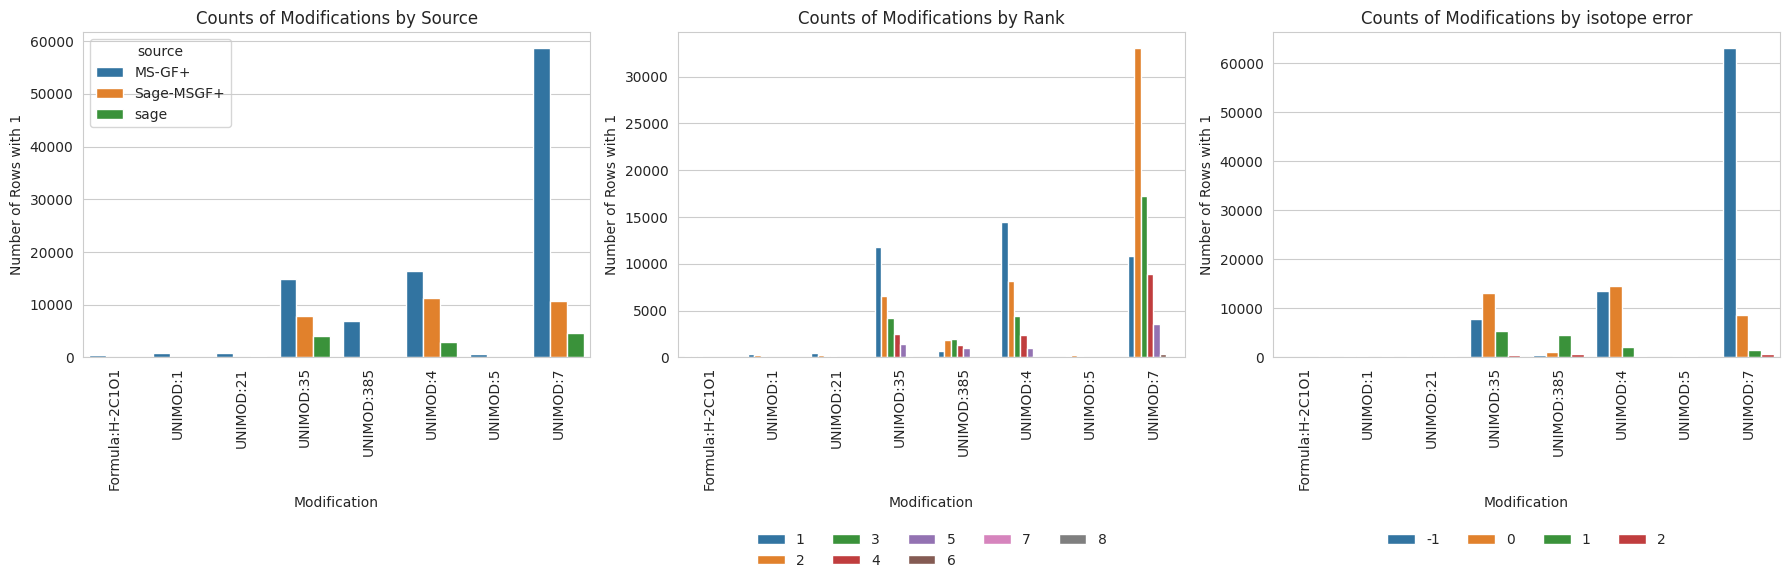

In [195]:
plot_characteristics(all_data_filtered)

Populate metaproteomics

In [244]:
import os

from denovo_utils.data import Run
from denovo_utils.parsers import DenovoEngineConverter
from denovo_utils.io.read import load_psmlist

import seaborn as sns
from matplotlib import pyplot as plt
%matplotlib inline

from denovo_utils.analysis.metrics import load_seq_score_dicts
from denovo_utils.analysis.metrics import get_match_score_table, get_prc_curve

from psm_utils import Peptidoform
from tqdm import tqdm
from peak_pack.utils import calculate_ppm

from denovo_utils.analysis.metrics import (
    get_refinement_error_tables,
    plot_refinement_error_table,
    plot_precision_recall_refinement
)

import pandas as pd

from pathlib import Path

from denovo_utils.io.read import read_partitions_features, read_partitions_psmlist
from denovo_utils.io.save import save_psmlist

from glob import glob

run_names = [
    'S03',
    'S05',
    'S07',
]

root_denovo_output = '/public/compomics3/Sam/PXD023217/denovo_output'
root_mgf = '/public/compomics3/Sam/PXD023217/mgf_filtered'
root_ground_truth = root_rescoring = '/public/compomics3/Sam/PXD023217/reviewer/rescoring'

engine_names = denovo_names = [
    'adanovo',
    'pihelixnovo',
    'piprimenovo',
    'casanovo',
    'instanovo',
    'contranovo',
    'novob',
    'pepnet',
]

runs = {}
for run_name in run_names:
    print(f"Run: {run_name}")
    run = Run(run_name)

    gt_path = os.path.join(root_rescoring, run_name, 'psmlist', 'sage_msgf.parquet')
    psmlist_gt = load_psmlist(gt_path)
    run.load_gold_standard(
        psmlist=psmlist_gt,
        score_name='score_ms2rescore',
        filter_decoys=True,
        filter_on_qvalue=True
    )

    for denovo_name in denovo_names:
        print(f'loading {denovo_name}')

        path_denovo_file = os.path.join(
            root_denovo_output,
            denovo_name,
            run_name + '.' + denovo_name + '.some_extension'
        )
        mgf_path = os.path.join(
            root_mgf, run_name+'.mgf'
        )
        parser = DenovoEngineConverter.select(denovo_name.replace('instanovo', 'instanovo_v11'))
        psmlist_denovo = parser.parse(
            result_path=path_denovo_file,
            mgf_path=mgf_path
        )
        run.load_psmlist(
            psmlist=psmlist_denovo,
            score_names=[],
            only_gold_standard_spectra=False
        )

    runs[run_name] = run

Run: S03
Q-value (True) filtering: 0 PSMs filtered.
Decoy filtering: 0 PSMs filtered.


Loading PSMs in Run object (S03): 100%|██████████| 168295/168295 [00:01<00:00, 158890.92it/s]


loading adanovo


Loading PSMs in Run object (S03): 100%|██████████| 136676/136676 [00:02<00:00, 47053.79it/s]


loading pihelixnovo


...

Loading PSMs in Run object (S07): 100%|██████████| 21691/21691 [00:00<00:00, 44887.72it/s]


loading novob


Loading PSMs in Run object (S07): 100%|██████████| 40981/40981 [00:00<00:00, 169738.23it/s]


loading pepnet


Loading PSMs in Run object (S07): 100%|██████████| 46808/46808 [00:01<00:00, 41205.84it/s]


In [248]:
with open('runs_PXD023217.pkl', 'wb') as f:
    pickle.dump(runs, f)